Timestep: 0
Timestep: 10  /  10000
Timestep: 20  /  10000
Timestep: 30  /  10000
Timestep: 40  /  10000
Timestep: 50  /  10000
Timestep: 60  /  10000
Timestep: 70  /  10000
Timestep: 80  /  10000
Timestep: 90  /  10000


<ipython-input-1-d75e2f49f8aa>:93: RuntimeWarning: divide by zero encountered in divide
  psi_bt = -(q1_s + q2_s) / (ll[np.newaxis, :] ** 2 + zk[:, np.newaxis] ** 2) / 2.      # (psi_1 + psi_2)/2
<ipython-input-1-d75e2f49f8aa>:93: RuntimeWarning: invalid value encountered in divide
  psi_bt = -(q1_s + q2_s) / (ll[np.newaxis, :] ** 2 + zk[:, np.newaxis] ** 2) / 2.      # (psi_1 + psi_2)/2


Timestep: 100  /  10000
Timestep: 110  /  10000
Timestep: 120  /  10000
Timestep: 130  /  10000
Timestep: 140  /  10000
Timestep: 150  /  10000
Timestep: 160  /  10000
Timestep: 170  /  10000
Timestep: 180  /  10000
Timestep: 190  /  10000
Timestep: 200  /  10000
Timestep: 210  /  10000
Timestep: 220  /  10000
Timestep: 230  /  10000
Timestep: 240  /  10000
Timestep: 250  /  10000
Timestep: 260  /  10000
Timestep: 270  /  10000
Timestep: 280  /  10000
Timestep: 290  /  10000
Timestep: 300  /  10000
Timestep: 310  /  10000
Timestep: 320  /  10000
Timestep: 330  /  10000
Timestep: 340  /  10000
Timestep: 350  /  10000
Timestep: 360  /  10000
Timestep: 370  /  10000
Timestep: 380  /  10000
Timestep: 390  /  10000
Timestep: 400  /  10000
Timestep: 410  /  10000
Timestep: 420  /  10000
Timestep: 430  /  10000
Timestep: 440  /  10000
Timestep: 450  /  10000
Timestep: 460  /  10000
Timestep: 470  /  10000
Timestep: 480  /  10000
Timestep: 490  /  10000
Timestep: 500  /  10000
Timestep: 510  /

FileNotFoundError: [Errno 2] No such file or directory: 'images/upper_level_streamfunction.png'

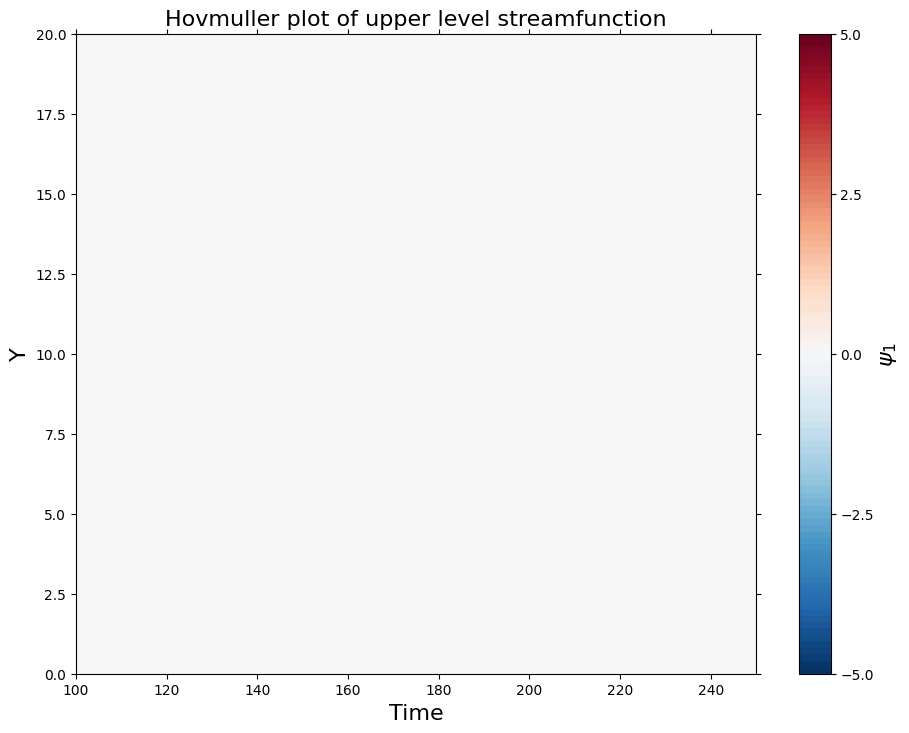

In [1]:
""""
Nicholas Lutsko -- AOS Program, Princeton

Zonally truncated 2-layer QG model after Held & Panetta 1988
Only keep 1 zonal wavenumber, default is k=0.7

The non-linear terms are calculated using the
Orszag (1971) alias-free transform method. Leapfrog
time-stepping is used for all terms except the
hyperdiffusion.

Here it just tracks the growth rate, the
domain-mean energy and the domain-mean enstrophy,
and also plots the zonal-mean streamfunction as a
function of time, but it can be easily modified to
do other things.

Last updated -- July 12th 2016
"""
import numpy as np
import math
import matplotlib.pylab as plt
from random import random


#######################################################
#  First declare some parameters, arrays, etc.

opt = 3 # 1 = just the linear parts, 2 = just the nonlinear parts, 3 = full model

N = 256 #size of spectral decomposition
L = 20. #size of domain -- stick to multiples of 10

nu = pow( 10., -3. ) #viscous dissipation
km = 0.3 #Ekman friction -- setting in PH88 is 0.3
kt = 0.067 #radiative damping -- value in PH88 is 0.067
bet = 0.15 #beta -- value in PH88 is 0.15
pi = math.pi #always useful

#Wavenumbers:
#Zonal wavenumbers:
MK = int(0.7 * L ) #Wavenumber to keep
zk = np.array([0., 0.7])

#Meridional wavenumbers:
ll = np.fft.fftfreq( N , L / 256. )

x = np.linspace( 0, 2. * pi * L, N ) #domain size
dt = 0.025 #Timestep
ts = 10000 #Total timesteps
lim = 2000 #Start taking averages from here

#Spectral arrays:
#Only need 3 time-steps
psic_1 = np.zeros( ( ( 3 , 2 , N ) ) ).astype( complex )
psic_2 = np.zeros( ( ( 3 , 2 , N ) ) ).astype( complex )
qc_1 = np.zeros( ( ( 3 , 2 , N ) ) ).astype( complex )
qc_2 = np.zeros( ( ( 3 , 2 , N ) ) ).astype( complex )

#Array for saving zonal-mean upper-level streamfunction
psi_1 = np.zeros( (ts, N ) )

#Track energy, enstrophy and growth rate:
en = np.zeros( ts )
ens = np.zeros( ts )
gr = np.zeros( ( int(ts - lim), int(N / 2) ) )


#######################################################
#  Some functions

def ft( psi ):
    """Fourier Transform and keep relevant coefficients"""
    temp1 = np.fft.fft2( psi )
    return temp1[: , 0 ] / N / N , temp1[:, MK ] / N / N

def ift( psic ):
    """Inverse Fourier Transform"""
    temp1 = np.fft.ifft( psic[ 0 ] )
    temp2 = np.fft.ifft( psic[ 1 ] )
    ps = temp1[ : , np.newaxis ] + temp2 [ : , np.newaxis ] * np.exp( 1.j * zk[1 ] * x[:] ) + ( temp2[ : , np.newaxis ].conjugate() ) * np.exp( -1.j * zk[1] * x[:] )
     #psi(x,y,t)  =  psi_0(y,t) + (psi_k(y,t)exp(ikx) + c.c)
    return ps

def ptq(ps1, ps2):
    """Calculate PV"""
    q1 = -(ll[np.newaxis, :] ** 2 + zk[:, np.newaxis] ** 2 ) * ps1 - (ps1 - ps2) / 2. # -(k^2 + l^2) * psi_1 -0.5*(psi_1-psi_2)
    q2 = -(ll[np.newaxis, :] ** 2 + zk[:, np.newaxis] ** 2 ) * ps2 + (ps1 - ps2) / 2. # -(k^2 + l^2) * psi_2 +0.5*(psi_1-psi_2)
    return q1, q2

def qtp(q1_s, q2_s):
    """Invert PV"""
    psi_bt = -(q1_s + q2_s) / (ll[np.newaxis, :] ** 2 + zk[:, np.newaxis] ** 2) / 2.      # (psi_1 + psi_2)/2
    psi_bc = -(q1_s - q2_s) / (ll[np.newaxis, :] ** 2 + zk[:, np.newaxis] ** 2 + 1.) / 2.  # (psi_1 - psi_2)/2
    psi_bt[0, 0] = 0.
    psi1 = psi_bt + psi_bc
    psi2 = psi_bt - psi_bc
    return psi1, psi2

def calcnl( psi, qc):
    """"Calculate dealiased non-linear terms"""
    ex = int(N * 3 / 2) #3/2*the total wavenumbers
    temp1 = np.zeros( ex ).astype( complex )
    temp2 = np.zeros( ex ).astype( complex )
    temp4 = np.zeros( N ).astype( complex )	#Final array
    #Pad values:
    temp1[:int(N/2)] = psi[:int(N/2)]
    temp1[ex-int(N/2):] = psi[int(N/2):]
    temp2[:int(N/2)] = qc[:int(N/2)]
    temp2[ex-int(N/2):] = qc[int(N/2):]
    #Fourier transform product, normalize, and filter:
    temp3 = np.fft.fft( np.fft.ifft( temp1 ) * np.fft.ifft( temp2 ) ) * 3. / 2.
    temp4[:int(N/2)] = temp3[:int(N/2)]
    temp4[int(N/2):] = temp3[ex-int(N/2):]
    return temp4

def nlterm(j, wpsi, psi, wqc, qc):
    """"Calculate non-linear terms"""
    if j == 0:
        NL1 = calcnl(wpsi, 1.j * ll * qc) #ik psi_k * dq_k^*/dy
        NL2 = calcnl(qc, 1.j * ll * wpsi) #ik q_k^* * d(psi_k)/dy
        NL3 = calcnl(psi, 1.j * ll * wqc) #ik psi_k^* * dq_k/dy
        NL4 = calcnl(wqc , 1.j * ll * psi) #ik q_k * d(psi_k^*)/dy
        return (1.j * zk[1] * (NL4 + NL3 - NL2 - NL1)).real

    else:
        NL1 = calcnl(qc, 1.j * ll * wpsi) #q_k * d(psi_0)/dy
        NL2 = calcnl(psi, 1.j * ll * wqc) #psi_k * d(q_0)/dy
        return 1.j * zk[1] * ( NL1 - NL2 )

def lterm(lay, k1, qc, psi, opsi, upsi, j):
    """"Calculate linear terms"""
    if lay == 1:
         return - 1.j * k1 * qc - 1.j * k1 * ( bet + 0.5 ) * psi + kt * (psi - upsi)
    else:
        return  - 1.j * k1 * ( bet - 0.5 ) * psi + km * ((k1 + ll) ** 2) * opsi + kt * (psi - upsi)



#######################################################
#  Initial conditions:

#Make ICs:
from random import random
psic_1[0] = [ [ random() * .0001  for i in range(N) ] for j in range(2) ]
psic_2[0] = [ [ random() * .0001  for i in range(N) ] for j in range(2) ]
psic_1[0, 0, 0 ] = 0.
psic_2[0, 0, 0 ] = 0.

#Transfer values:
psic_1[ 1 , : , : ] = psic_1[ 0 , : , : ]
psic_2[ 1 , : , : ] = psic_2[ 0 , : , : ]

#Calculate initial PV
qc_1[0], qc_2[0] = ptq(psic_1[0], psic_2[0])
qc_1[1], qc_2[1] = ptq(psic_1[1], psic_2[1])

#Take first norms:
en[0] = np.linalg.norm(psic_1[0, 0] + psic_1[0, 1] ) #Energy
ens[0] = np.linalg.norm(qc_1[0, 1] + qc_1[0, 0] ) #Enstrophy


#######################################################
#  Time-stepping functions

def fs(ovar, rhs, det, jk):
    """Forward Step: q^t-1 / ( 1 + 2. * dt * nu * (k^4 + l^4 ) ) + RHS"""
    mult = det / ( 1. + det * nu * (zk[jk] ** 4 + ll ** 4) )
    return mult * (ovar / det + rhs)

def lf(oovar, rhs, det, jk):
    """Leap frog timestepping: q^t-1 / ( 1 + 2. * dt * nu * (k^4 + l^4 ) ) + RHS"""
    mult = 2. * det / ( 1. + 2. * det * nu * (zk[jk] ** 4 + ll ** 4) )
    return mult * (oovar / det / 2. + rhs)

g = 0.04 #filter coefficient
def filt(var, ovar, nvar):
    """Leapfrog filtering"""
    return var + g * (ovar - 2. * var + nvar )


#######################################################
#  Main time-stepping loop

print ("Timestep:", 0)

forc1 = np.zeros(N).astype(complex)
forc2 = np.zeros(N).astype(complex)
nl1 = np.zeros(N).astype(complex)
nl2 = np.zeros(N).astype(complex)

#Timestepping:
for i in range(1, ts):

    if i % 10 == 0:
        print ("Timestep:", i, " / ", ts)

    #Calculate conjugates:
    qcc_1 = np.fft.fft( np.fft.ifft(qc_1[1, 1] ).conjugate() )
    qcc_2 = np.fft.fft( np.fft.ifft(qc_2[1, 1] ).conjugate() )
    pcc_1 = np.fft.fft( np.fft.ifft(psic_1[1, 1] ).conjugate() )
    pcc_2 = np.fft.fft( np.fft.ifft(psic_2[1, 1] ).conjugate() )

    #Calculate timestep
    for j in range(2):
        if opt > 1:
           if j == 0:
                nl1 = nlterm(j, psic_1[1, 1], pcc_1, qc_1[1, 1], qcc_1)
                nl2 = nlterm(j, psic_2[1, 1], pcc_2, qc_2[1, 1], qcc_2)
           else:
                nl1 = nlterm(j, psic_1[1, 0], psic_1[1, 1], qc_1[1, 0], qc_1[1, 1])
                nl2 = nlterm(j, psic_2[1, 0], psic_2[1, 1], qc_2[1, 0], qc_2[1, 1])
        if opt != 2:
            forc1[:] = lterm(1, zk[j], qc_1[1, j, :], psic_1[1, j, :], psic_1[0, j, :], psic_2[1, j, :], j)
            forc2[:] = lterm(2, zk[j], qc_2[1, j, :], psic_2[1, j, :], psic_2[0, j, :], psic_1[1, j, :], j)

        rhs1 = nl1[:] + forc1[:]
        rhs2 = nl2[:] + forc2[:]

        if i == 1:
		#Forward step
        	qc_1[2, j] = fs(qc_1[1, j, :], rhs1[:], dt, j)
        	qc_2[2, j] = fs(qc_2[1, j, :], rhs2[:], dt, j)
        else:
		#Leapfrog step
        	qc_1[2, j, :] = lf(qc_1[0, j, :], rhs1[:], dt, j)
        	qc_2[2, j, :] = lf(qc_2[0, j, :], rhs2[:], dt, j)
        if i > 1:
		#Leapfrog filter
                qc_1[1, j] = filt(qc_1[1, j], qc_1[0, j], qc_1[2, j])
                qc_2[1, j] = filt(qc_2[1, j], qc_2[0, j], qc_2[2, j])

    #Invert:
    psic_1[1], psic_2[1] = qtp(qc_1[2], qc_2[2] )
    psic_1[0], psic_2[0] = qtp(qc_1[1], qc_2[1] )

    #Growth rate, norms
    if i > lim:
        gr[i-lim, :] =  np.log( abs( psic_1[1, 1, :int(N/2)] ) / abs( psic_1[0, 1, :int(N/2)] ) ) / dt #Growth rate
    en[i] = np.linalg.norm(psic_1[1, 0] + psic_1[1, 1] ) #Energy
    ens[i] = np.linalg.norm(qc_1[1, 0] + qc_1[1, 1] ) #Enstrophy


    psi_1[i, :] = np.mean( ift( psic_1[1] ), axis = 1 ).real

    #Transfer values:
    qc_1[0, :, :] = qc_1[1, :, :]
    qc_2[0, :, :] = qc_2[1, :, :]
    qc_1[1, :, :] = qc_1[2, :, :]
    qc_2[1, :, :] = qc_2[2, :, :]


time = np.arange(0, ts * dt, dt)
y = np.linspace( 0., L, 256 )
v = np.linspace( -5., 5., 100 )

fig = plt.figure( figsize = (10, 8) )
plt.subplots_adjust( left = 0.1, right = 0.95, bottom = 0.1, top = 0.9 )

ax = plt.subplot( 1, 1, 1 )
plt.title("Hovmuller plot of upper level streamfunction", fontsize = 16)

plt.contourf( time, y, np.swapaxes( psi_1, 0, 1), v, cmap = plt.cm.RdBu_r )
cbar = plt.colorbar(ticks = [-5., -2.5, 0., 2.5, 5.])
cbar.set_label(r"$\psi_1$", fontsize = 16 )

plt.xlabel("Time", fontsize = 16)
plt.ylabel("Y", fontsize = 16)
ax.tick_params(axis = 'x', which = 'both', direction = 'out', top = 'off')
ax.tick_params(axis = 'y', which = 'both', direction = 'out', right = 'off')

plt.xlim([100., 250.])

ax.patch.set_facecolor('k')
ax.patch.set_alpha(0.25)

plt.savefig("images/upper_level_streamfunction.png")
plt.show()

